# 28회차 기출문제 

## 문제 1

**Data description**

-   sex : 성별

-   age : 나이

-   pstatus : 부모와의 동거 유무(T : 동거 o, A : 동거 x)

-   medu : 엄마의 교육수준

    -   0 : none

    -   1 : 초등교육(초등학교)

    -   2 : 5 \~ 9th edu

    -   3 : 중등교육(중학교, 고등학교)

    -   4 : 고등교육(대학, 대학원수준)

-   fedu : 아빠의 교육수준

    -   0 : none

    -   1 : 초등교육(초등학교)

    -   2 : 5 \~ 9th edu(5\~9학년)

    -   3 : 중등교육(중학교, 고등학교)

    -   4 : 고등교육(대학, 대학원수준)

-   guardian : 주보호자

    -   어머니

    -   아버지

    -   기타

-   traveltime : 등하교기간

    -   1 : 15분 이하

    -   2 : 15분 \~ 30분 이하

    -   3 : 30분 \~ 1시간 이하

    -   4 : 1시간 이상

-   studytime : 학습시간

    -   1 : 2시간 이하

    -   2 : 2\~5시간 이하

    -   3 : 5\~10시간 이하

    -   4 : 10시간 이상

-   failure : 학사경고 횟수

-   freetime : 자유시간(1 : 매우 낮음 \~ 5 : 매우 높음)

-   famrel : 가족관계(1 : 매우나쁨 \~ 5 : 매우우수)

-   absences : 결석 유무

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

In [45]:
d1 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/28/problem1.csv')
d1.head()

,sex,age,pstatus,medu,fedu,guardian,traveltime,studytime,failures,freetime,famrel,absences
0,F,18,A,4,4,mother,2,2,0,3,4,No
1,F,17,T,1,1,father,1,2,0,3,5,No
2,F,15,T,1,1,mother,1,2,3,3,4,No
3,F,15,T,4,2,mother,1,3,0,2,3,No
4,F,16,T,3,3,father,1,2,0,3,4,No


1.  **EDA를 실시하시오(5점).**

In [47]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sex         395 non-null    object
 1   age         395 non-null    int64 
 2   pstatus     395 non-null    object
 3   medu        395 non-null    int64 
 4   fedu        395 non-null    int64 
 5   guardian    395 non-null    object
 6   traveltime  395 non-null    int64 
 7   studytime   395 non-null    int64 
 8   failures    395 non-null    object
 9   freetime    395 non-null    int64 
 10  famrel      395 non-null    int64 
 11  absences    395 non-null    object
dtypes: int64(7), object(5)
memory usage: 37.2+ KB


In [46]:
d1.isna().sum()

sex           0
age           0
pstatus       0
medu          0
fedu          0
guardian      0
traveltime    0
studytime     0
failures      0
freetime      0
famrel        0
absences      0
dtype: int64

결측치는 없다. info 결과 일부 명목형 변수가 number형으로 표시된 것을 확인할 수 있다.  
object 형으로 변환한다.   
- 대상컬럼: 'medu', 'fedu', 'traveltime', 'studytime', 'freetime', 'famrel'  

다음으로 시각화를 포함한 통계량을 확인한다.

<<연속형 변수 통계량 및 시각화>>


,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0


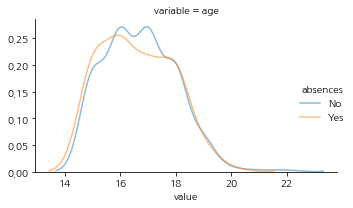

<<명목형 변수 통계량 및 시각화>>


,count,unique,top,freq
sex,395,2,F,208
pstatus,395,2,T,354
medu,395,5,4,131
fedu,395,5,2,115
guardian,395,3,mother,273
traveltime,395,4,1,257
studytime,395,4,2,198
failures,395,6,0,286
freetime,395,5,3,157
famrel,395,5,4,195


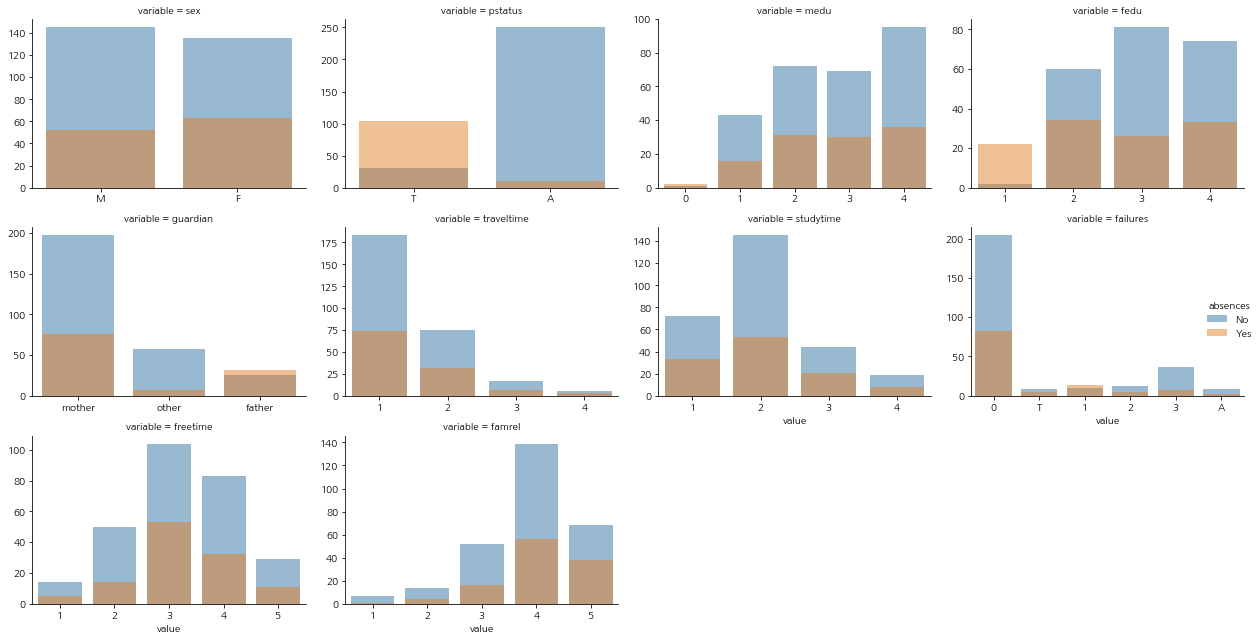

In [74]:
cg_cols = ['medu', 'fedu', 'traveltime', 'studytime', 'freetime', 'famrel']

d1[cg_cols] = d1[cg_cols].astype('O')

c_cols = d1.select_dtypes('O').columns.tolist()
n_cols = d1.select_dtypes('number').columns.tolist()

print("<<연속형 변수 통계량 및 시각화>>")
display(d1[n_cols].describe().T)
mt = d1.melt(id_vars='absences', value_vars=n_cols)
g = sns.FacetGrid(mt, col='variable', hue='absences', col_wrap=1, height=3, aspect=1.4, sharex=False, sharey=False)
g.map(sns.kdeplot, 'value', alpha=0.5)
g.add_legend()
plt.tight_layout()
plt.show()
print("<<명목형 변수 통계량 및 시각화>>")
display(d1[c_cols].describe().T)
mt = d1.melt(id_vars='absences', value_vars=c_cols[:-1])
g = sns.FacetGrid(mt, col='variable', hue='absences', col_wrap=4, height=3, aspect=1.4, sharex=False, sharey=False)
g.map(sns.countplot, 'value', alpha=0.5)
g.add_legend()
plt.tight_layout()
plt.show()

나이는 오른쪽 긴 꼬리 분포를 보이며, 16세에서 가장 많고, 20세부터 빈도가 급격히 줄어듬(즉, 일반적인 중-고등학생 나이)    
종속변수 기준으로 분포는 비슷하나, 지각하지 않은 학생의 16-18세 구간의 비율이 더 높으며, 22세로 나이많은 학생 데이터 관측  
종속변수를 기준으로 명목형 변수의 분포를 비교하면, 결석한 학생의 경우 부모와 동거하지 않는 경우가 확연히 많으며,    
아버지의 교육수준이 비교적 낮은 편이다.(무학 비율 높음)  
주양육자는 어머니 비율이 높으나, 아버지의 비율도 높은 편이다.   
또한 지각하지 않은 학생에 비해 낙제 1회 한 횟수가 더 많다.   

=> 일반 중고생 대비 나이가 많으며, 부모와 동거하지 않고, 아버지의 교육수준이 낮은 경우 결석하는 경향 관찰  

위 데이터에서 이상치로 식별되는 데이터는 없으므로 boxplot, iqr을 통한 이상치 확인은 생략한다. 

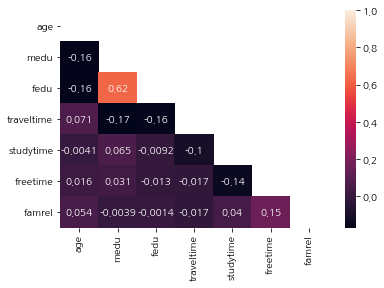

In [76]:
df_rr = d1.copy()
df_rr[cg_cols] = df_rr[cg_cols].astype('int')

corr = df_rr.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

앞서 object형으로 변환했던 변수는 순위형 명목변수로 피어슨 선형 상관관계분석을 위해 수치형으로 변환 후 검정을 실시한다. 
1:1 피처 상관관계에서 엄마-아빠 교육수준은 0.62로 양의 상관관계가 있음을 알 수 있다.  
(엄마 교육수준이 높아지면 아빠 교육수준도 높아짐)  

이 결과만으로 다중공선성 여부를 알 수 없기 때문에 vif로 다중공선성을 확인한다. 

## 1-2. 데이터 품질을 살펴보고, 차원축소가 필요한지 검토하시오(5점)

In [77]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
names = df_rr.select_dtypes('number').columns
vif['name'] = names
vif['vif'] = [variance_inflation_factor(df_rr[names].values, i) for i in range(len(names))]
display(vif[1:])

,name,vif
1,medu,12.018302
2,fedu,10.348885
3,traveltime,5.427227
4,studytime,6.964743
5,freetime,11.694615
6,famrel,20.138432


medu, fedu, freetime, famrel에서 10 이상의 높은 다중공선성이 식별된다.  
이는 각 변수 간 비슷한 정보들을 담고 있어 모델학습 성능에 악영향을 주므로 차원축소를 고려한다.  

(단, 대부분의 변수는 다시 object 형으로 one-hot 인코딩을 할 것이라 pca 미적용)

## 1-3. 위에서 적용한 것이 과적합이라는 전제하, 해결하기 위한 방법을 2개 제시 및 구현(5점)

과적합은 train set에 지나치게 학습되어, 일반화 성능이 떨어짐을 의미한다.  
train set의 성능은 뛰어나나, test set 등 train set에 포함되지 않는 데이터에서는 낮은 성능을 보인다.  
모델학습을 하는 의미는 분포가 비슷한 다른 데이터에서도 학습데이터와 비슷한 성능을 기대하기 때문이다.  

1. 앙상블 모델 사용: 배깅, 부스팅 등 여러 모델 병렬학습을 통해 일반화 성능 향상(여기서는 배깅 기반 랜덤포레스트 사용)
2. 모델 단순화: 가중치 규제 모델인 릿지(L2), 라쏘(L1) 모델을 사용하여 가중치 제어를 통해 복잡도 감소(여기서는 릿지모델 사용)

In [91]:
d1['absences'].value_counts()

No     280
Yes    115
Name: absences, dtype: int64

(296, 11) (296,)
랜덤포레스트 - train
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       210
         Yes       1.00      1.00      1.00        86

    accuracy                           1.00       296
   macro avg       1.00      1.00      1.00       296
weighted avg       1.00      1.00      1.00       296



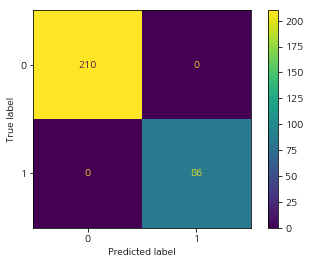

랜덤포레스트 - test
              precision    recall  f1-score   support

          No       0.69      0.90      0.78        70
         Yes       0.12      0.03      0.05        29

    accuracy                           0.65        99
   macro avg       0.41      0.47      0.42        99
weighted avg       0.53      0.65      0.57        99



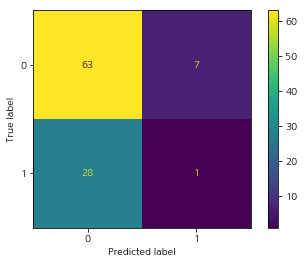

릿지모델 - train
              precision    recall  f1-score   support

          No       0.74      0.99      0.84       210
         Yes       0.80      0.14      0.24        86

    accuracy                           0.74       296
   macro avg       0.77      0.56      0.54       296
weighted avg       0.76      0.74      0.67       296



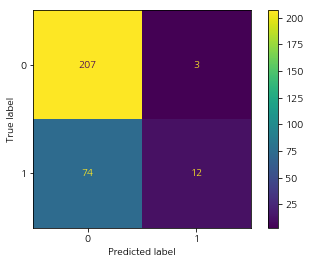

릿지모델 - test
              precision    recall  f1-score   support

          No       0.71      0.93      0.81        70
         Yes       0.38      0.10      0.16        29

    accuracy                           0.69        99
   macro avg       0.54      0.52      0.48        99
weighted avg       0.61      0.69      0.62        99



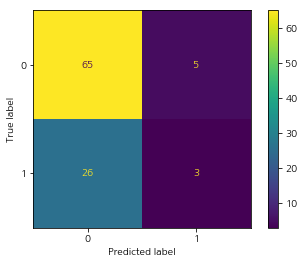

In [123]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
#데이터 분할
x = d1.drop('absences', axis=1)
y = d1['absences']

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42, stratify=y)
print(train_x.shape, train_y.shape)

n_cols = train_x.select_dtypes('number').columns
c_cols = train_x.select_dtypes('O').columns

processor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler())]), n_cols),
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

processor2 = make_column_transformer(
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

#중간규제=0.01, 강한규제: 1이상
rg = Pipeline([
    ('processor', processor), 
    ('cl', RidgeClassifier(alpha=0.01))
])

rf = Pipeline([
    ('processor', processor2), 
    ('cl', RandomForestClassifier(random_state=42))
])


m_list = [('랜덤포레스트', rf), ('릿지모델', rg)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

for m_name, model in m_list:
    model.fit(train_x, train_y)
    for d_name, x, y in d_list:
        pred = model.predict(x)
        print(f"{m_name} - {d_name}")
        print(classification_report(y, pred))
        cm = confusion_matrix(y, pred)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot()
        plt.show()

랜덤포레스트 모델은 여전히 과적합이 심하게 나타나지만, 릿지모델은 레이블 1의 예측성능은 여전히 낮지만  
f1 score 기준 train/test set macro 성능이 0.54 , 0.48로 랜덤포레스트 대비 과적합 정도가 나은 것을 알 수 있다.

## 4.  **Random forest, neural network, Lightgbm 알고리즘 적용하여 F1 score를 구하고 성능을 비교하시오(5점).**

랜덤포레스트 - train
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       210
           1       1.00      1.00      1.00        86

    accuracy                           1.00       296
   macro avg       1.00      1.00      1.00       296
weighted avg       1.00      1.00      1.00       296



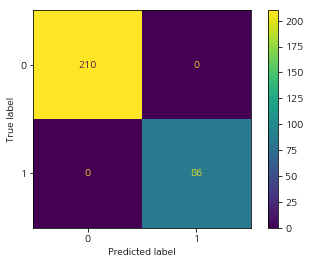

랜덤포레스트 - test
              precision    recall  f1-score   support

           0       0.69      0.90      0.78        70
           1       0.12      0.03      0.05        29

    accuracy                           0.65        99
   macro avg       0.41      0.47      0.42        99
weighted avg       0.53      0.65      0.57        99



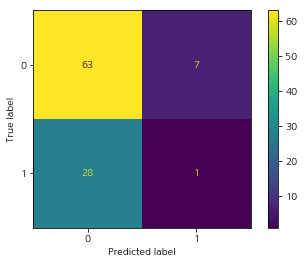

뉴럴넷 - train
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       210
           1       0.97      0.86      0.91        86

    accuracy                           0.95       296
   macro avg       0.96      0.93      0.94       296
weighted avg       0.95      0.95      0.95       296



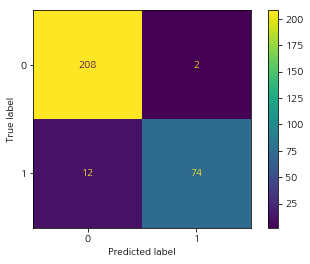

뉴럴넷 - test
              precision    recall  f1-score   support

           0       0.69      0.76      0.72        70
           1       0.23      0.17      0.20        29

    accuracy                           0.59        99
   macro avg       0.46      0.46      0.46        99
weighted avg       0.55      0.59      0.57        99



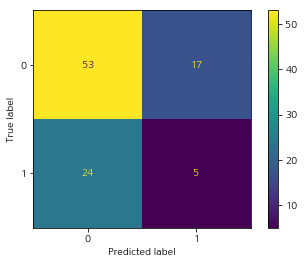

lgbm - train
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       210
           1       0.95      0.65      0.77        86

    accuracy                           0.89       296
   macro avg       0.91      0.82      0.85       296
weighted avg       0.90      0.89      0.88       296



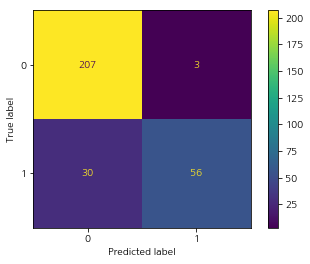

lgbm - test
              precision    recall  f1-score   support

           0       0.70      0.81      0.75        70
           1       0.28      0.17      0.21        29

    accuracy                           0.63        99
   macro avg       0.49      0.49      0.48        99
weighted avg       0.58      0.63      0.60        99



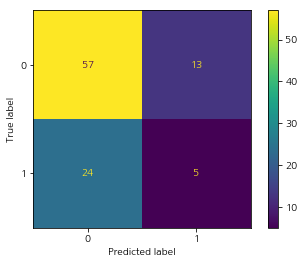

,모델명,데이터,f1_score
0,랜덤포레스트,train,1.000000
1,랜덤포레스트,test,0.418331
2,뉴럴넷,train,0.940511
3,뉴럴넷,test,0.458583
4,lgbm,train,0.849294
5,lgbm,test,0.483866


In [128]:
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

train_y, test_y = le.fit_transform(train_y), le.transform(test_y)


rf = Pipeline([
    ('processor', processor2), 
    ('cl', RandomForestClassifier(random_state=42))
])

mlp = Pipeline([
    ('processor', processor), 
    ('cl', MLPClassifier(random_state=42))
])

lgbm = Pipeline([
    ('processor', processor2), 
    ('cl', LGBMClassifier(random_state=42))
])

m_list = [('랜덤포레스트', rf), ('뉴럴넷', mlp), ('lgbm', lgbm)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['모델명', '데이터', 'f1_score'])

for m_name, model in m_list:
    model.fit(train_x, train_y)
    for d_name, x, y in d_list:
        pred = model.predict(x)
        print(f"{m_name} - {d_name}")
        print(classification_report(y, pred))
        f1 = f1_score(pred, y, average='macro')
        rs.loc[len(rs)] = [m_name, d_name, f1]
        cm = confusion_matrix(y, pred)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot()
        plt.show()
display(rs)

세 모델의 학습 결과이다. 세 모델 모두 과적합이 식별되었다.  
macro f1_score 결과, test set 기준 lgbm의 점수가 0.483866로 가장 높아 해당 모델을 채택한다. 

## 5.  하드 보팅 기법을 적용하고, 이전 결과와 비교하시오(5점)

하드보팅 기법은 다숙결 원칙에 따라 각 분류기의 예측 클래스 레이블을 투표로 결합, 가장 많은 투표를 받은 클래스가 최종 예측값이 된다.  
앙상블 기법으로 볼 수 있으며, 여러 모델 결과를 통해 일반화된 결과를 출력할 수 있다. 
- 장점: 구현 간단, 직관적, 확률정보 없는 모델도 사용 가능, 계산비용 낮음
- 단점: 소프트보팅 대비 낮은 성능

lgbm - train
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       210
           1       0.97      0.88      0.93        86

    accuracy                           0.96       296
   macro avg       0.96      0.94      0.95       296
weighted avg       0.96      0.96      0.96       296



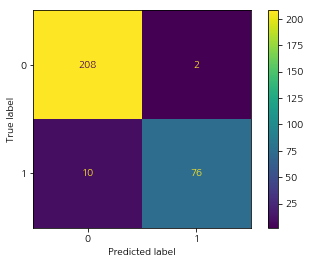

lgbm - test
              precision    recall  f1-score   support

           0       0.68      0.83      0.75        70
           1       0.14      0.07      0.09        29

    accuracy                           0.61        99
   macro avg       0.41      0.45      0.42        99
weighted avg       0.52      0.61      0.56        99



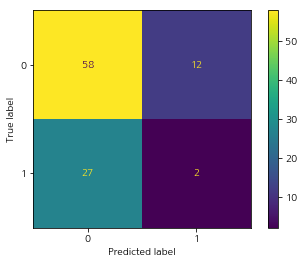

In [132]:
from sklearn.ensemble import VotingClassifier

h_vote = VotingClassifier(
        estimators = [
            ('rf', rf), 
            ('mlp', mlp), 
            ('lgbm', lgbm)], 
    voting = 'hard')

h_vote.fit(train_x, train_y)


for d_name, x, y in d_list:
    pred = h_vote.predict(x)
    print(f"{m_name} - {d_name}")
    print(classification_report(y, pred))
    f1 = f1_score(pred, y, average='macro')
    rs.loc[len(rs)] = ['하드보팅', d_name, f1]
    cm = confusion_matrix(y, pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.show()

In [133]:
display(rs)

,모델명,데이터,f1_score
0,랜덤포레스트,train,1.000000
1,랜덤포레스트,test,0.418331
2,뉴럴넷,train,0.940511
3,뉴럴넷,test,0.458583
4,lgbm,train,0.849294
5,lgbm,test,0.483866
6,하드보팅,train,0.949396
7,하드보팅,test,0.420705


하드보팅 결과, test set 기준 최고성능 모델인 lgbm보다 낮은 f1_score인 0.420705를 기록했는데  이는 랜덤포레스트보다 높으며,  
뉴럴넷, lgbm 보다 낮은 성능이다. 세 모델의 일반화 성능이라고 할 수 있다. 

## 6.  추가적인 처리 방안이 있으면 제시하시오(5점)

여전히 과적합이 관찰된다. 과적합을 완화하기 위해 가중치 조절 모델인 릿지, 앙상블 모델인 랜덤포레스트, 그리고 뉴럴넷 모델인 
mlp를 사용하였는데 과적합이 완화되지 않았다.  

추가적인 방법으로는 
1. 데이터 증강: 현실적으로 가능하다면 가장 좋은 방법이다. 데이터의 수가 충분히 많다면 일반화 성능을 보여줄 수 있을 것이다. 
2. elary stopping: 과적합이 되기 전에 빠르게 학습을 끝내는 방법이다. 
3. dropout: 뉴럴넷에서 과적합을 방지하기 위한 기법으로, 학습 시 일부 뉴런을 비활성화하는 기법 

## 7.  학교 운영시스템에 적용한다면 검토사항은 무엇이 있을지 제시하시오(5점)

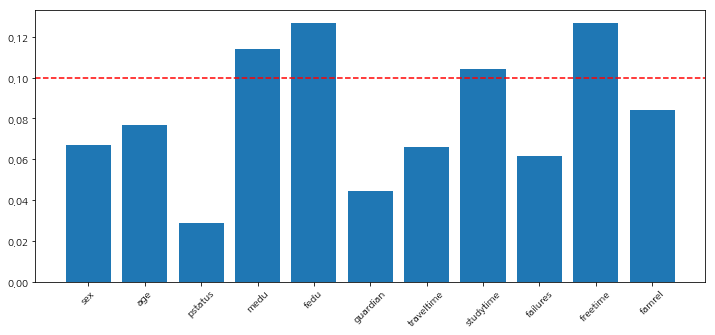

In [172]:
from sklearn.inspection import permutation_importance


f_imp = permutation_importance(rf, train_x, train_y, n_repeats=10, random_state=42)

f = train_x.columns
imp = f_imp.importances_mean
plt.figure(figsize=(12, 5))
plt.bar(f, imp)
plt.xticks(rotation=45)
plt.axhline(y=0.1, color='r', linestyle='--')
plt.show()

모델 학습 간 학습성능에 중요한 영향을 끼진 변수를 permutaion importance로 확인할 수 있다.  
best 모델인 lgbm의 train set을 10번 학습한 결과이다.  
medu, fedu 순으로 중요한 영향을 미침을 알 수 있다. 

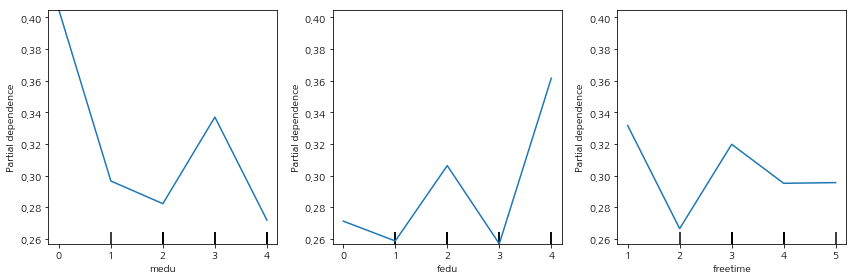

In [150]:
from sklearn.inspection import partial_dependence
from sklearn.inspection import plot_partial_dependence

s_col = ['medu', 'fedu', 'freetime']

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
plt.subplots_adjust(top=0.9, hspace=0.7)

plot_partial_dependence(estimator=rf, 
                       X=train_x, 
                       features=s_col, 
                       percentiles=(0, 1), 
                       ax = ax)
plt.tight_layout()
plt.show()

랜덤포레스트 기반이 해석이 쉬우므로 해당 모델을 사용한다.(train set기준은 성능이 비슷하므로)   
train set 기준 휴식시간이 2인 경우 결석이 가장 낮은 경향이 있다. 

## 문제 2

**Data description**

-   **customer_id :** 고객의 고유 ID

-   **age : 나이**

-   **income** : 고객의 월 수입

-   **email_open_rate** : 고객이 이메일을 연 비율

-   **campaign_type : 마케팅 캠페인 타입**

    -   'Sale', 'Discount', 'NewArrival'

-   **clicks : 고객이 마케팅 캠페인에서 클릭한 횟수(target)**

In [190]:
d2 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/28/problem2.csv')

## 1.  데이터 전처리를 수행하시오.

In [191]:
d2.isna().sum()

Unnamed: 0         0
customer_id        0
age                0
income             0
clicks             0
email_open_rate    0
campaign_type      0
dtype: int64

결측치는 없다. 데이터의 분포 및 통계량을 확인한다. 

In [192]:
d2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       200 non-null    int64  
 1   customer_id      200 non-null    int64  
 2   age              200 non-null    int64  
 3   income           200 non-null    int64  
 4   clicks           200 non-null    int64  
 5   email_open_rate  200 non-null    float64
 6   campaign_type    200 non-null    object 
dtypes: float64(1), int64(5), object(1)
memory usage: 11.1+ KB


In [193]:
d2.drop(columns = d2.columns[:2], inplace=True)

<<연속형 변수 통계량 및 시각화>>


,count,mean,std,min,25%,50%,75%,max
age,200.0,49.820,5.246449,37.0,46.00,49.00,53.00,62.0
income,200.0,6139.970,2260.529173,2015.0,4489.00,6220.50,8057.25,9968.0
clicks,200.0,5.025,2.375413,0.0,3.00,5.00,6.00,14.0
email_open_rate,200.0,0.470,0.300888,0.0,0.19,0.45,0.73,1.0


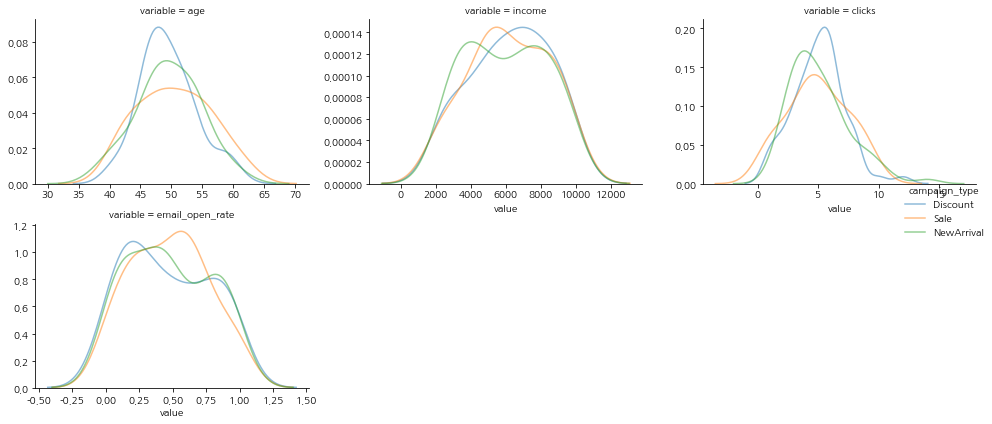

<<명목형 변수 통계량 및 시각화>>


,count,unique,top,freq
campaign_type,200,3,NewArrival,72


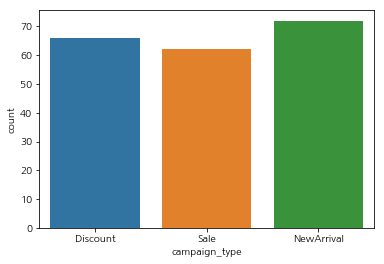

In [194]:
c_cols = d2.select_dtypes('O').columns.tolist()
n_cols = d2.select_dtypes('number').columns.tolist()

print("<<연속형 변수 통계량 및 시각화>>")
display(d2[n_cols].describe().T)
mt = d2.melt(id_vars='campaign_type', value_vars=n_cols)
g = sns.FacetGrid(mt, col='variable', hue='campaign_type', col_wrap=3, height=3, aspect=1.4, sharex=False, sharey=False)
g.map(sns.kdeplot, 'value', alpha=0.5)
g.add_legend()
plt.tight_layout()
plt.show()
print("<<명목형 변수 통계량 및 시각화>>")
display(d2[c_cols].describe().T)
sns.countplot(d2['campaign_type'])
plt.show()

campaign_type에 따라 age, click수의 분포의 차이가 있다.

## 2.  캠페인 타입이 'Sale'인지 여부에 따라 새로운 파생변수를 생성하시오.

In [195]:
d2['type'] = np.where(d2['campaign_type'] == 'Sale', 1, 0)

print(d2['type'].value_counts())

0    138
1     62
Name: type, dtype: int64


## 3.  포아송 회귀 모델을 적합하고, 모델의 통계적 유의성을 검토하시오.

In [196]:
ratio = d2['clicks'].var(ddof=1) / d2['clicks'].mean()

print(f"분산/평균의 비: {ratio}")

분산/평균의 비: 1.1229030725768143


포아송 모델은 분산/평균비를 1로 가정하므로 위 결과 1에 가까운 1.129이므로 적절하다고 할 수 있다.  

유의수준 5% 하에서 포아송 회귀모델 적합 후 우도비 검정을 통해 검정을 실시한다.  

- 귀무가설: 포아송 모델이 통계적으로 유의하지 않다.(모든 회귀계수가 0이다.)
- 대립가설: 포아송 모델이 통계적으로 유의하다.(적어도 1개의 회귀계수는 0이 아니다.)

In [200]:
from statsmodels.api import GLM, families
from scipy.stats import chi2

formula = 'clicks ~ age + income + email_open_rate + C(type)'

model = GLM.from_formula(formula, data=d2, family=families.Poisson()).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 clicks   No. Observations:                  200
Model:                            GLM   Df Residuals:                      195
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -451.55
Date:                Thu, 25 Sep 2025   Deviance:                       232.34
Time:                        17:57:06   Pearson chi2:                     222.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007820
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.3969      0.329     

In [201]:
#우도비 검정
s = model.null_deviance - model.deviance
rv = chi2(loc=0, scale=1, df=model.df_model)
p = 1-rv.cdf(s)

print("우도비검정 통계량", s)
print("우도비 검정통계량의 pvalue: ", p)

우도비검정 통계량 1.5702067597662506
우도비 검정통계량의 pvalue:  0.8141366515862866


우도비 검정 결과, p-value가 0.8141366515862866로 귀무가설을 기각할 수 없다.  
따라서 모델은 통계적으로 유의하지 않다.  
(포아송 모델이 통계적으로 유의하지 않다.(모든 회귀계수가 0이다.))

## 4.  회귀 계수의 통계적 유의성을 확인하고, 해석하시오.

-   $H0$: 각 변수의 회귀계수는 0이다.

-   $H1$: 각 변수의 회귀계수는 0이 아니다.


유의수준 5% 하에서 모든 설명변수의 p-value가 0.05 이상이므로 귀무가설을 기각할 수 없다.  
따라서 모든 설명변수와 종속변수(clicks) 간 통계적으로 유의미한 관계가 없다.

In [207]:
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 clicks   No. Observations:                  200
Model:                            GLM   Df Residuals:                      195
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -451.55
Date:                Thu, 25 Sep 2025   Deviance:                       232.34
Time:                        18:10:37   Pearson chi2:                     222.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007820
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.3969      0.329     

모델이 통계적으로 유의하다고 가정하고 각 설명변수의 통계적 유의성을 검정한다.  
유의수준 5% 하에서 모든 변수의 p-value가 0.05보다 크므로 모든 변수의 회귀계수는 통계적 유의성이 없다.  
(회귀계수는 0이다.)

## 5. Random forest 모델을 적합하고, 포아송 회귀와 모델 성능을 비교(평가지표 : RMSE)

In [214]:
x.head()

,age,income,email_open_rate,type_1
0,46,6707,0.49,0
1,57,6018,0.78,1
2,56,3518,0.80,0
3,52,2015,0.68,0
4,41,9021,0.58,1


In [221]:
from sklearn.metrics import mean_squared_error

x = d2.drop(columns=['clicks', 'campaign_type'])
y = d2['clicks']

x = pd.get_dummies(x, columns=['type'], drop_first=True)

rf = RandomForestClassifier(random_state=42)
rf.fit(x, y)

print("포아송 회귀모델 성능")
pred1 = model.predict(d2)
rmse1 = np.sqrt(mean_squared_error(y, pred1))
print(f"rmse: {rmse1}")

print("랜덤포레스트 회귀모델 성능")
pred2 = rf.predict(x)
rmse = np.sqrt(mean_squared_error(y, pred2))
print(f"rmse: {rmse}")

포아송 회귀모델 성능
rmse: 2.360660724227497
랜덤포레스트 회귀모델 성능
rmse: 0.0


In [223]:
2.4/(y.max() - y.min())

0.17142857142857143

전체 데이터를 기준으로 학습 후 rmse로 회귀모델 성능을 비교한 결과이다.  
랜덤포레스트는 표준오차가 0으로 아주 정확한 성능을 보여주고 있으며, 포아송 회귀모델은 rmse가 2.36으로 전체 종속변수 범위(14) 대비  
표준오차 2.360660724227497로 약 17%의 오차가 존재한다.  
따라서 배깅기반 앙상블 모델인 랜덤포레스트 모델이 해당 문제에 더 적합하다. 

## 문제 3

### 1.  시간별, 제조사별 불량률 데이터로 생존분석을 시행한 후 25, 30, 35개월 후의 불량률을 계산하시오(5점)

Kaplan-Meier 생존 함수 또는 Cox 비례위험모형을 사용하여 생존분석 가능

In [5]:
d3 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/28/problem3.csv')

d3.head()

,time,status,company
0,8,1,X
1,10,1,X
2,8,0,X
3,12,1,X
4,20,1,X


비모수 생존분석 방법인 Kaplan-Meier 추정을 통해 생존분석을 시행한다.   

- 누적생존함수를 경험적 방식으로 추정, 검열 데이터 처리 가능, 시각적 비교 용이
- 공변량 효과를 직접 모형화하지 못하며, 복잡한 다변량 분석 불가능


X
25 개월 후 생존확률: 64.17 % / 불량률: 35.83 %
30 개월 후 생존확률: 64.17 % / 불량률: 35.83 %
35 개월 후 생존확률: 55.00 % / 불량률: 45.00 %

Y
25 개월 후 생존확률: 56.25 % / 불량률: 43.75 %
30 개월 후 생존확률: 46.88 % / 불량률: 53.12 %
35 개월 후 생존확률: 28.13 % / 불량률: 71.87 %


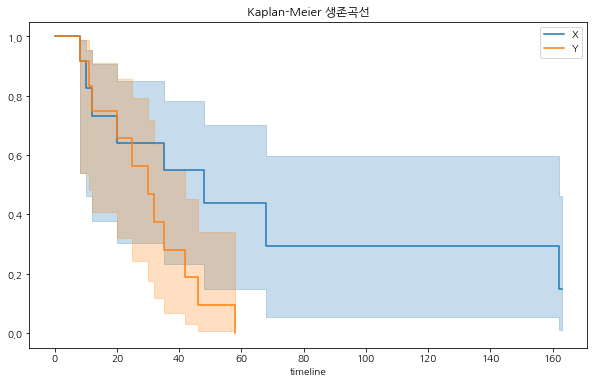

In [13]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

for com in d3['company'].unique():
    sub_com = d3[d3.company == com]
    kmf.fit(
    durations = sub_com['time'],
    event_observed=sub_com['status'],
    label=com
)
    
    print(f"\n{com}")
    for t in [25, 30, 35]:
        s = kmf.survival_function_at_times(t).values[0]
        f_rate = 1 - s #고장률
        print(f"{t} 개월 후 생존확률: {s*100:.2f} % / 불량률: {f_rate*100:.2f} %")
    kmf.plot_survival_function()
plt.title("Kaplan-Meier 생존곡선")
plt.show()    

25, 30, 35개월 모두 X회사의 생존확률이 높다.  X 회사는 생존확률 저하속도가 낮으며, 30개월까지는 64.14%의 생존확률을 보이다가  
35개월 들어서는 55% 다소 감소한다.  
Y회사는 생존확률 감소가 급격하며, 60개월 구간에 이르러서는 생존확률이 0에 수렴한다. .

### 2.  로그 순위법으로 제조사별 불량률의 차이가 있는지 검정하시오(5점)

로그 순위법은 두 생존 곡선이 차이가 있는지 검정하는 비모수적 방법입니다.  
`survdiff` 함수에 구현되어 있으며, 유의 수준 0.05에서 검정을 실시하는 방법입니다.

-   $H_0$: 두 생존 함수는 동일하다. $S_X(t) = S_Y(t)$ for all $t$
-   $H_1$: 두 생존 함수는 같지 않다. $S_X(t) \neq S_Y(t)$ for some $t$

In [17]:
from lifelines.statistics import logrank_test

com_x = d3[d3.company == 'X']
com_y = d3[d3.company == 'Y']

rt = logrank_test(com_x['time'], com_y['time'], 
                 event_observed_A=com_x['status'], 
                 event_observed_B=com_y['status'])

p_value = rt.p_value

print(f"로그순위 테스트 결과: {p_value} 귀무가설", "기각" if p_value < 0.05 else "기각불가")

로그순위 테스트 결과: 0.05629401724877395 귀무가설 기각불가


유의수준 5% 하 로그순위 테스트 결과, p-value가  0.05629401724877395로 귀무가설을 기각할 수 없다.  
따라서 두 회사의 생존함수는 동일하며, 제조사별 불량률의 차이는 유의하지 않다.

## 문제 4

별도의 데이터 없음

**다음 표는 슬통 Food의 신제품 홍보 설문 조사 결과이다. 시식 행사에 참여한 고객들의 시식 후 구매 의사의 변화가 있는지 없는지 검정하시오(10점).**

| 구분         | 시식 후 있음 | 시식 후 없음 |
|--------------|--------------|--------------|
| 시식 전 있음 | 23           | 7            |
| 시식 전 없음 | 18           | 12           |

-   $H_0$ : 시식 전후 구매의사에는 변화가 없다.
-   $H_1$ : 시식 전후 구매의사에는 변화가 있다.

명목변수의 전후 비교 문제이므로 비모수검정인 맥니머 검정을 시행한다. 

In [24]:
from statsmodels.stats.contingency_tables import mcnemar

#b+c가 25이상이므로 correction False가능(7+18)
d4 = np.array([[23, 18], 
              [7, 12]])
rs = mcnemar(d4, exact=False, correction=False) #카이제곱 근사치 사용여부, 연속성 수정여부
print(f"맥니머 검정 통계량: {rs.statistic}")
print(f"p-value: {rs.pvalue:3f}")

맥니머 검정 통계량: 4.84
p-value: 0.027807


유의수준 5% 하에서 p-value가 0.027807로 작으므로 귀무가설을 기각, 시식 전후 구매의사에는 변화가 있다.는 통계적으로 유의

## 문제 5

**두 개의 고등학교 학생들의 시험 표준 점수가 들어있습니다. 각 학생의 성적이 서로 독립적이라고 가정할 때, 두 학교의 표준 점수 분포에 유의미한 차이가 있는지 검정하시오(10점).**

In [27]:
d5 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/28/problem5.csv')

In [28]:
d5.head()

,school_A,school_B
0,89.0,94
1,44.0,49
2,66.0,69
3,25.0,30
4,78.0,37


In [29]:
d5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   school_A  12 non-null     float64
 1   school_B  24 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 512.0 bytes


두 학교 학생의 표준점수 분포에 차이가 있는지 검정하기 위해 정규성을 만족한다면 독립검정 ttest를 시행하고,  
정규성을 만족하지 않는다면 맨휘트니 u검정을 시행한다. 

In [37]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, levene

#정규성 검정
for name, g in zip(['A', 'B'],  [d5['school_A'].dropna(), d5['school_B'].dropna()]):
    stat, p = shapiro(g)
    print(f"{name} shapiro 정규성 검정결과: 정규성", "만족" if p >= 0.05 else "불만족")
#정규성을 만족하므로 등분산성 여부 확인
stat, p = levene(d5['school_A'], d5['school_B'])
print(f"levene 등분산성 검정결과: 등분산성", "만족" if p >= 0.05 else "불만족")

#등분산성 불만족으로 welch's ttest 독립검정 수행
stat, p = ttest_ind(d5['school_A'], d5['school_B'], equal_var=False, nan_policy='omit')
print(f"welch's ttest 독립검정 결과: 통계량({stat:.3f}) / pvalue({p:.3f})")

A shapiro 정규성 검정결과: 정규성 만족
B shapiro 정규성 검정결과: 정규성 만족
levene 등분산성 검정결과: 등분산성 불만족
welch's ttest 독립검정 결과: 통계량(1.050) / pvalue(0.306)


정규성은 만족하나, 등분산성 가정을 만족하지 않아 welch's ttest 독립검정을 수행하였다.  
통계량(1.050) / pvalue(0.306)로 유의수준 5% 하에서 두 학교 학생의 표준점수 분포는 같다. 라는 귀무가설을 기각할 수 없다.  
따라서 두 학교 학생의 표준점수 분포는 다르지 않다. 

혹은 데이터의 수가 30보다 확연히 적으므로 중심극한의 정리를 만족하지 않아 비모수 검정인 ks 검정 수행(누적분포함수 cdf 비교)

In [42]:
A = d5['school_A'].dropna()
B = d5['school_B'].dropna()

from scipy.stats import ks_2samp

stat, p = ks_2samp(A, B)

print(f"KS 검정 통계량: {stat:.3f}")
print(f"p-value: {p:.3f}")

KS 검정 통계량: 0.292
p-value: 0.485


## 문제 6

슬통 병원 환자들의 건강 검진 정보가 들어있습니다. 다음의 물음에 답하시오.

In [36]:
d6 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/28/problem6.csv')

In [38]:
d6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4098 entries, 0 to 4097
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HCHK_YEAR         4098 non-null   int64  
 1   IDV_ID            4098 non-null   int64  
 2   SIDO              4098 non-null   int64  
 3   SEX               4098 non-null   int64  
 4   AGE_GROUP         4098 non-null   int64  
 5   HEIGHT            4098 non-null   int64  
 6   WEIGHT            4098 non-null   int64  
 7   WAIST             4097 non-null   float64
 8   BP_HIGH           4098 non-null   int64  
 9   BP_LWST           4098 non-null   int64  
 10  BLDS              4098 non-null   int64  
 11  TOT_CHOLE         4098 non-null   int64  
 12  HMG               4098 non-null   int64  
 13  SMK_STAT_TYPE_CD  4095 non-null   float64
 14  DRK_YN            4098 non-null   int64  
dtypes: float64(2), int64(13)
memory usage: 480.4 KB


In [39]:
# SMK_STAT_TYPE_CD  에 3개의 결측치 삭제
d6 = d6.dropna()

In [40]:
d6.head()

,HCHK_YEAR,IDV_ID,SIDO,SEX,AGE_GROUP,HEIGHT,WEIGHT,WAIST,BP_HIGH,BP_LWST,BLDS,TOT_CHOLE,HMG,SMK_STAT_TYPE_CD,DRK_YN
0,2021,1711106,11,2,13,145,50,87.0,113,58,88,44,8,1.0,1
1,2021,1307592,44,1,9,180,90,97.0,136,86,85,44,16,2.0,1
2,2021,2888541,47,1,14,165,60,91.0,123,93,155,50,11,3.0,1
3,2021,1358453,26,1,16,160,55,102.0,120,80,85,52,7,2.0,0
4,2021,4392436,45,2,17,150,55,74.0,136,96,85,54,6,1.0,0


1.  **몸무게를 제어했을 때, 나이와 콜레스테롤 상관계수 및 유의확률을 구하라(5점).**

편상관계수는 제3의 변수(몸무게)의 영향을 통제하여 두 변수 간의 순수한 상관관계를 파악할 때 매우 유용한 통계 기법으로   
해당기법을 활용하여 상관계수 및 유의확률을 구함

유의수준 5% 하에서 다음의 가설 수립

-   $H_0$ : 몸무게를 통제했을 때, 나이와 콜레스테롤의 상관계수는 0이다.

-   $H_1$ : 몸무게를 통제했을 때, 나이와 콜레스테롤의 상관계수는 0이 아니다.

In [44]:
import pingouin as pg
rs = pg.partial_corr(data=d6, x='AGE_GROUP', y='TOT_CHOLE', covar='WEIGHT')
display(rs)

,n,r,CI95%,r2,adj_r2,p-val,BF10,power
pearson,4094,0.017208,"[-0.01, 0.05]",0.000296,-0.000193,0.270991,0.036,0.196241


편상관계수: 0.017208, 유의확률: 0.270991

2.  **유의수준 0.05 하에서 통계적 의사결정을 수행하라(5점).**

유의수준 5% 하에서 유의확률(p-value)이 0.270991으로 0.05보다 크므로 귀무가설을 기각할 수 없음.  
따라서 몸무게를 통제했을 때, 나이와 콜레스테롤의 상관계수는 0이다.